INFO:purepyindi2.transports:Connected to localhost:7624


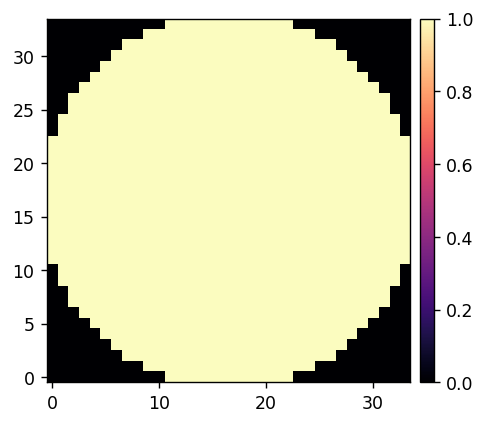

In [9]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import dm, utils, rt_utils, coro_utils, scoob_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

In [2]:
def power_nsv455(client, toggle=True, ):
    client.wait_for_properties([
        'nsv455.power',
    ])
    if toggle:
        client[f'nsv455.power.toggle'] = purepyindi.SwitchState.ON
        time.sleep(10)
    else:
        client[f'nsv455.power.toggle'] = purepyindi.SwitchState.OFF
        time.sleep(2)


In [3]:
power_nsv455(client0,)

In [4]:
reload(coro_utils)
coro_utils.set_nsv455_roi(
    client0,
    mode='8096x6324',
)

In [7]:
reload(coro_utils)
coro_utils.set_cam_exp_time(0.001, client0, cam_name='nsv455')

Set the nsv455 exposure time to 1.00e-03s


In [5]:
reload(coro_utils)
coro_utils.set_nsv455_fps(client0, fps=4)

In [6]:
reload(coro_utils)
coro_utils.set_cam_blacklevel(20, client0, cam_name='nsv455')

Set the nsv455 blacklevel to 20.0


In [8]:
reload(coro_utils)
coro_utils.set_nsv455_roi(
    client0,
    # xc=5450, yc=3000,
    xc=5250,
    # yc=3200,
    yc=3520,
    # npix=1024,
    # npix=512,
    npix=2048,
)

In [5]:
reload(coro_utils)
coro_utils.set_nsv455_fps(client0, fps=4)

Could not import pylablib. NKT laser functionality not available.


In [15]:
reload(coro_utils)
coro_utils.set_cam_exp_time(0.0001, client0, cam_name='nsv455')

Could not import pylablib. NKT laser functionality not available.
Set the nsv455 exposure time to 1.00e-04s


In [9]:
reload(coro_utils)
coro_utils.set_nsv455_roi(
    client0,
    mode='512x512',
)

In [10]:
reload(coro_utils)
coro_utils.set_nsv455_fps(client0, fps=40)

In [4]:
def set_nsv455_roi_start(
        client, 
        xs=None, 
        ys=None, 
        delay=0.5,
    ):
    # update roi parameters
    client.wait_for_properties([
        'nsv455.sensor_roi_start_x',
        'nsv455.sensor_roi_start_y',
    ])

    if xs is not None:
        client['nsv455.sensor_roi_start_x.target'] = xs
        time.sleep(delay)
    if ys is not None:
        client['nsv455.sensor_roi_start_y.target'] = ys
        time.sleep(delay)

    # client['nsv455.roi_set.request'] = purepyindi.SwitchState.ON
    # time.sleep(delay)

In [10]:
np.floor(5000/16).astype(int) * 16

4992

In [6]:

set_nsv455_roi_start(
    client0,
    xs=np.floor(5000/16).astype(int) * 16,
    ys=3800,
)

In [10]:
reload(coro_utils)
scoob_utils.set_nsv455_roi(
    client0,
    # xc=5450, yc=3000,
    xc=256,
    yc=350,
    # npix=1024,
    # npix=512,
    npix=256,
)

In [ ]:

# for i in range(xs_vals.shape[0]):
#     for j in range(ys_vals.shape[0]):
#         try:
#             input("Press Enter to move to the next iteration...")
#             set_nsv455_roi_start(
#                 client0,
#                 xs=xs_vals[i],
#                 ys=ys_vals[j],
#             )
#         except KeyboardInterrupt:
#             break


In [13]:
power_nsv455(client0, 0)